In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('data.sqlite')

In [2]:
products_df = pd.read_sql_query("SELECT * FROM products", conn)
products_df.head()

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP
0,S10_1678,1969 Harley Davidson Ultimate Chopper,Motorcycles,1:10,Min Lin Diecast,"This replica features working kickstand, front...",7933,48.81,95.70
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,1:10,Highway 66 Mini Classics,"Official Moto Guzzi logos and insignias, saddl...",6625,68.99,118.94
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,1:10,Red Start Diecast,"Model features, official Harley Davidson logos...",5582,91.02,193.66
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,3252,85.68,136.00


In [3]:
od_df = pd.read_sql_query("SELECT * FROM orderDetails", conn)
od_df.head()

,orderNumber,productCode,quantityOrdered,priceEach,orderLineNumber
0,10100,S18_1749,30,136.00,3
1,10100,S18_2248,50,55.09,2
2,10100,S18_4409,22,75.46,4
3,10100,S24_3969,49,35.29,1
4,10101,S18_2325,25,108.06,4


In [4]:
# Need to make buyPrice numeric
products_df['buyPrice'] = products_df['buyPrice'].astype(float)
products_df.dtypes

productCode            object
productName            object
productLine            object
productScale           object
productVendor          object
productDescription     object
quantityInStock        object
buyPrice              float64
MSRP                   object
dtype: object

In [6]:
# Getting Data using Slicing syntax
foo_df1 = products_df[products_df['buyPrice'] >= 50]
foo_df1.head()

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,1:10,Highway 66 Mini Classics,"Official Moto Guzzi logos and insignias, saddl...",6625,68.99,118.94
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,1:10,Red Start Diecast,"Model features, official Harley Davidson logos...",5582,91.02,193.66
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,3252,85.68,136.00
5,S10_4962,1962 LanciaA Delta 16V,Classic Cars,1:10,Second Gear Diecast,Features include: Turnable front wheels; steer...,6791,103.42,147.74


In [7]:
# Using The query method
foo_df2 = products_df.query('buyPrice >= 50')
foo_df2.head()

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30
2,S10_2016,1996 Moto Guzzi 1100i,Motorcycles,1:10,Highway 66 Mini Classics,"Official Moto Guzzi logos and insignias, saddl...",6625,68.99,118.94
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,1:10,Red Start Diecast,"Model features, official Harley Davidson logos...",5582,91.02,193.66
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,3252,85.68,136.00
5,S10_4962,1962 LanciaA Delta 16V,Classic Cars,1:10,Second Gear Diecast,Features include: Turnable front wheels; steer...,6791,103.42,147.74


In [8]:
# These two lines are equivalent!
print(foo_df1.shape, foo_df2.shape)

(62, 9) (62, 9)


In [9]:
foo_df = products_df.query("buyPrice >= 50 & productLine == 'Classic Cars'")
foo_df.head()

,productCode,productName,productLine,productScale,productVendor,productDescription,quantityInStock,buyPrice,MSRP
1,S10_1949,1952 Alpine Renault 1300,Classic Cars,1:10,Classic Metal Creations,Turnable front wheels; steering function; deta...,7305,98.58,214.30
4,S10_4757,1972 Alfa Romeo GTA,Classic Cars,1:10,Motor City Art Classics,Features include: Turnable front wheels; steer...,3252,85.68,136.00
5,S10_4962,1962 LanciaA Delta 16V,Classic Cars,1:10,Second Gear Diecast,Features include: Turnable front wheels; steer...,6791,103.42,147.74
6,S12_1099,1968 Ford Mustang,Classic Cars,1:12,Autoart Studio Design,"Hood, doors and trunk all open to reveal highl...",68,95.34,194.57
7,S12_1108,2001 Ferrari Enzo,Classic Cars,1:12,Second Gear Diecast,Turnable front wheels; steering function; deta...,3619,95.59,207.80


In [10]:
from pandasql import sqldf

In [11]:
pysqldf = lambda q: sqldf(q, globals())

In [12]:
# Query for Pandas
top_5_query_pandas = """
SELECT productCode, productName, SUM(quantityOrdered) AS TotalOrdered
FROM products_df
JOIN od_df
USING (productCode)
GROUP BY productCode
ORDER BY TotalOrdered DESC
LIMIT 5
"""

In [13]:
# Query for SQL
top_5_query_sql = """
SELECT productCode, productName, SUM(quantityOrdered) AS TotalOrdered
FROM products
JOIN orderDetails
USING (productCode)
GROUP BY productCode
ORDER BY TotalOrdered DESC
LIMIT 5
"""

# Creating Pandas DataFrame

In [14]:
top_5 = pysqldf(top_5_query_pandas)
top_5.head()

,productCode,productName,TotalOrdered
0,S18_3232,1992 Ferrari 360 Spider red,1808
1,S18_1342,1937 Lincoln Berline,1111
2,S700_4002,American Airlines: MD-11S,1085
3,S18_3856,1941 Chevrolet Special Deluxe Cabriolet,1076
4,S50_1341,1930 Buick Marquette Phaeton,1074


In [15]:
# Direct to Pandas
top_5_best = pd.read_sql_query(top_5_query_sql, conn)
top_5_best.head()

,productCode,productName,TotalOrdered
0,S18_3232,1992 Ferrari 360 Spider red,1808
1,S18_1342,1937 Lincoln Berline,1111
2,S700_4002,American Airlines: MD-11S,1085
3,S18_3856,1941 Chevrolet Special Deluxe Cabriolet,1076
4,S50_1341,1930 Buick Marquette Phaeton,1074


In [17]:
top_5_best.describe()

,TotalOrdered
count,5.000000
mean,1230.800000
std,323.001084
min,1074.000000
25%,1076.000000
50%,1085.000000
75%,1111.000000
max,1808.000000


In [18]:
# Calculate the percentage of total sales for each product among the top 5
total_sales = top_5_best['TotalOrdered'].sum()

# Add as a new column
top_5_best['SalesPercentage'] = (top_5_best['TotalOrdered'] / total_sales) * 100

top_5_best.head()

,productCode,productName,TotalOrdered,SalesPercentage
0,S18_3232,1992 Ferrari 360 Spider red,1808,29.379266
1,S18_1342,1937 Lincoln Berline,1111,18.053299
2,S700_4002,American Airlines: MD-11S,1085,17.630809
3,S18_3856,1941 Chevrolet Special Deluxe Cabriolet,1076,17.484563
4,S50_1341,1930 Buick Marquette Phaeton,1074,17.452064


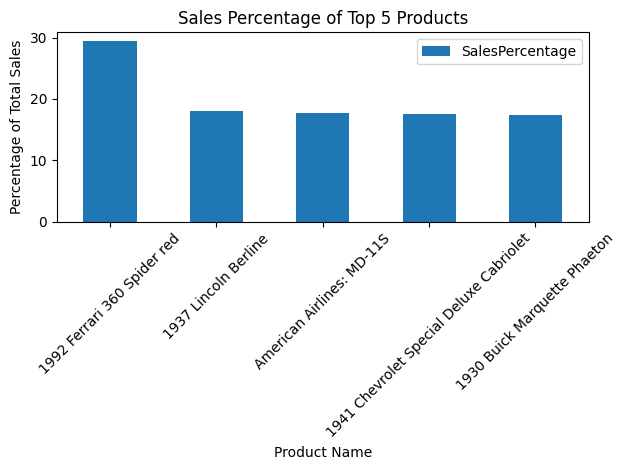

In [19]:
import matplotlib.pyplot as plt

top_5_best.plot(x='productName', y='SalesPercentage', kind='bar')
plt.title('Sales Percentage of Top 5 Products')
plt.xlabel('Product Name')
plt.ylabel('Percentage of Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
conn.close()